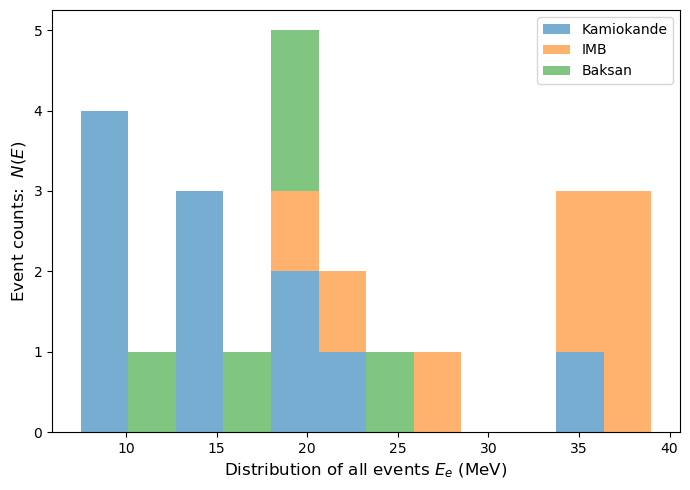

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from Pycode import SignalRate
from Pycode import Data
from Pycode import definition as df


fix_0 = [12.597, 5.036, 4.688, 0.291, 2.179, 0.527, 0, 0]
fix_1 = [12.597, 5.036, 4.688, 0.291, 2.179, 0.527, 30, 30]  # best fit six-parameter
fix_2 = [12.597, 5.036, 4.688, 0.291, 2.179, 0.527, 420, 108]

fix_3 = [12.597, 5.036, 4.688, 0.291, 2.179, 0.527, 100, 50]

E_hist = np.concatenate((Data.Kam_E, Data.IMB_E, Data.Baksan_E), axis=0)
dE_hist = np.concatenate((Data.Kam_dE, Data.IMB_dE, Data.Baksan_dE), axis=0)


Ex = np.linspace(1,50,500)

def SR_E(c, t, E, *theta):

    return (np.where(E<=4, 0, SignalRate.SR_K(t, E, c, *theta))
            +np.where(E<=19, 0, SignalRate.SR_I(t, E, c, *theta))
            +np.where(E<=10, 0, SignalRate.SR_B(t, E, c, *theta)))

def SR_E_K(c, t, E, *theta):

    return np.where(E<=4, 0, SignalRate.SR_K(t, E, c, *theta))
       
def SR_E_B(c, t, E, *theta):

    return np.where(E<=10, 0, SignalRate.SR_B(t, E, c, *theta))

def SR_E_I(c, t, E, *theta):

    return np.where(E<=19, 0, SignalRate.SR_I(t, E, c, *theta))


# # --- 绘图 ---
fig, ax = plt.subplots(figsize=(7,5))

ax.hist(
    [Data.Kam_E, Data.IMB_E, Data.Baksan_E],
    bins=12,
    stacked=True,          
    # color=["red", "blue", "green"],
    label=["Kamiokande", "IMB", "Baksan"],
    alpha=0.6              
)

# ax.errorbar(E_hist, xerr=dE_hist, xerr_width=1, fmt='o', color='black', capsize=3, markersize=5)
# 格式化
ax.set_xlabel(r"Distribution of all events $E_e$ (MeV)", fontsize=12)
ax.set_ylabel("Event counts:  $N(E)$", fontsize=12)
ax.legend()
plt.tight_layout()